# Chapter 8 — Aperture Synthesis & the *uv*-plane

!!! info "Before you start"
    **Prerequisites:** Ch 7 (Why Interferometry?) · **Maths Lab:** [Lab A (Fourier & Convolution)](31_mathslab_fourier_convolution.ipynb) · **~50 min** · **Intermediate**

In **Chapter 7** we built a two-element interferometer and watched the fringes:
a single baseline measures one *visibility* — one Fourier component of the sky.
A single number is not an image. This chapter is the leap from *"a pair of
antennas measures a fringe"* to *"an array of antennas, turned by the spinning
Earth, measures a picture"*. That leap is **aperture synthesis**, and it earned
[**Sir Martin Ryle**](https://www.nobelprize.org/prizes/physics/1974/ryle/facts/)
a share of the 1974 Nobel Prize in Physics.

The central idea is one of the most beautiful in observational astronomy:

> An interferometer does not measure the sky directly. It measures the
> **Fourier transform** of the sky brightness, sampled at the spatial
> frequencies $(u, v)$ picked out by its baselines.

If you can sample enough of that Fourier plane, you can transform back and
recover the image. A handful of antennas only samples a handful of points — but
as the Earth rotates, each baseline sweeps an *arc* through the $(u,v)$-plane,
filling it in for free. This is **Earth-rotation synthesis**.

### Learning goals

By the end of this chapter you will be able to:

- State the **van Cittert–Zernike theorem**: that the measured visibility is the
  Fourier transform of the sky brightness distribution, and explain what $(u,v)$
  coordinates *are*.
- Show, in code, how **Earth rotation** fills the $(u,v)$-plane and why that
  matters for image quality.
- Define the **dirty beam** (the point-spread function — the transform of the
  $uv$ sampling) and the **dirty image** (the true sky convolved with that
  beam), and read the **sidelobes** off a plot.
- Verify the Fourier relationship *explicitly*: FFT the model sky, multiply by
  the sampling mask, inverse-FFT, and confirm it reproduces the dirty image
  pixel-for-pixel.

This sets up **Chapter 9 (CLEAN)**, where we *deconvolve* the dirty beam back
out of the dirty image to recover a clean picture of the sky.

## The history: Ryle and the synthesised aperture

The resolution of any telescope is set by its diameter $D$ relative to the
wavelength $\lambda$: roughly $\theta \approx \lambda / D$ radians (dropping the
1.22 Rayleigh factor for this order-of-magnitude estimate). At radio
wavelengths $\lambda$ is enormous — for the 21 cm hydrogen line, $\lambda =
0.21\,\mathrm{m}$ — so to match the arcsecond resolution of a backyard optical
telescope you would need a dish *kilometres* across. Nobody can build a steerable
dish a kilometre wide.

**Martin Ryle** and his group at Cambridge found the way around this in the 1950s
and 60s. Instead of one giant dish, use many small antennas and combine their
signals in pairs. Each pair (each **baseline**) of length $b$ behaves, for
imaging purposes, like a tiny piece of a dish of diameter $b$. Crucially, you do
not need to fill in the whole dish at once: you can **synthesise** the aperture
of a huge instrument by sampling many different baselines over time — including
the extra baselines handed to you, free of charge, by the rotation of the Earth.
For developing aperture-synthesis imaging, Ryle shared the
**1974 Nobel Prize in Physics** with Antony Hewish (the first Nobel awarded for
astronomy).

The conceptual seed appears already in **Ryle & Vonberg (1946)**, *Solar
Radiation on 175 Mc/s* (Nature **158**, 339,
[DOI](https://doi.org/10.1038/158339b0)) — one of the first radio
interferometers, used to resolve the radio Sun. The technique matured over the
following two decades into the full Earth-rotation synthesis arrays that lead
directly to instruments like the VLA, ALMA and the SKA.

The mathematical foundation underneath all of this is the **van Cittert–Zernike
theorem** (P. H. van Cittert, 1934; F. Zernike, 1938), which connects the
*spatial coherence* of the radiation arriving at two points to the *brightness
distribution* of the source. The standard modern treatment — the interferometry
"bible" — is:

> **Thompson, A. R., Moran, J. M. & Swenson, G. W.**,
> *Interferometry and Synthesis in Radio Astronomy* (3rd ed., Springer, open
> access). See also **Condon & Ransom**, *Essential Radio Astronomy*
> ([free online](https://science.nrao.edu/opportunities/courses/era)).

## The physics: visibilities and the van Cittert–Zernike theorem

### What a baseline measures

Point an interferometer at a patch of sky and set up coordinates on that patch:
let $(l, m)$ be **direction cosines** — angular offsets (in radians, for small
fields) from the phase centre, with $l$ towards the East and $m$ towards the
North. Let $I(l, m)$ be the sky **brightness** in that direction.

A baseline between two antennas, projected onto the plane perpendicular to the
line of sight, has a length and orientation we measure in **wavelengths** and
write as $(u, v)$. So $u$ and $v$ are *spatial frequencies*: a long baseline
samples fine structure (high spatial frequency), a short baseline samples coarse
structure (low spatial frequency).

The complex quantity the correlator produces for that baseline is the
**visibility** $V(u, v)$. The **van Cittert–Zernike theorem** says it is the
two-dimensional Fourier transform of the sky brightness:

$$
\boxed{\;V(u, v) \;=\; \iint I(l, m)\,
  e^{-2\pi i\,(u\,l + v\,m)}\;\mathrm{d}l\,\mathrm{d}m \;}
$$

That box is the whole chapter in one line. **An interferometer is a Fourier
machine.** Each baseline hands you the value of $\hat I$ — the transform of the
sky — at one point $(u, v)$. By the Hermitian symmetry of the transform of a real
sky, the same measurement also gives you the conjugate point $(-u, -v)$ for free.

### Why we never measure the whole transform

To recover $I(l, m)$ perfectly we would need $V(u, v)$ at *every* $(u, v)$. A real
array gives us samples only where it has baselines. Write the **sampling
function** $S(u, v)$ as a sum of delta functions, one per measured visibility:

$$
S(u, v) \;=\; \sum_k \delta(u - u_k,\; v - v_k).
$$

What we actually invert is the *sampled* transform $S \cdot V$. By the
**convolution theorem**, multiplying in the $uv$-plane is convolving in the image
plane, so the image we get back — the **dirty image** $I_\mathrm{D}$ — is the
true sky convolved with the transform of the sampling function:

$$
I_\mathrm{D}(l, m) \;=\; \mathcal{F}^{-1}\!\big[\,S \cdot V\,\big]
  \;=\; I(l, m) \;\ast\; B(l, m),
\qquad
B(l, m) \;\equiv\; \mathcal{F}^{-1}\!\big[\,S\,\big].
$$

Here $B$ is the **dirty beam** (also called the *point-spread function*, PSF, or
*synthesised beam*): it is what a single point source looks like after passing
through your incomplete sampling. A perfectly filled $uv$-plane would give a
clean, narrow $B$; the ragged, hole-riddled sampling of a real array gives a $B$
with a central peak surrounded by **sidelobes** — ripples and spokes that smear
flux across the image. Chapter 9's CLEAN exists precisely to undo this
convolution.

### Earth-rotation synthesis

Here is Ryle's trick. The projected baseline $(u, v)$ depends on the *orientation*
of the physical baseline relative to the source direction. As the Earth turns,
the source moves across the sky, and each fixed antenna pair is presented to it
at a continuously changing angle. So a single baseline traces out an **arc** (in
general, an ellipse) in the $uv$-plane over the course of an observation. With
$N$ antennas you have $N(N-1)/2$ baselines, and Earth rotation sweeps each of
them into an arc — turning a sparse snapshot into a richly sampled plane, for
the cost of nothing but time.

The `jansky.interferometry.uv_coverage` helper implements exactly this: given
antenna positions and a set of **hour angles** (the source's angle past the
meridian, which advances with Earth rotation), it returns all the $(u, v)$
samples, conjugates included.

## Setup

We lean on the course helpers in `jansky.interferometry` and `jansky.plotting`
so the teaching code stays short and we can focus on the *ideas*. Nothing is
hidden — open `src/jansky/interferometry.py` any time to see the few lines of
NumPy underneath.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from jansky import interferometry, plotting
from jansky.plotting import use_jansky_style, plot_uv_coverage, show_image

use_jansky_style()
rng = np.random.default_rng(8)  # reproducible 'randomness' for this chapter

print("Helpers loaded:")
print("  interferometry:", [n for n in interferometry.__all__])
print("  plotting:      ", [n for n in plotting.__all__])

Helpers loaded:
  interferometry: ['uv_coverage', 'grid_visibilities', 'dirty_beam', 'dirty_image', 'hogbom_clean', 'CleanResult']
  plotting:       ['use_jansky_style', 'plot_uv_coverage', 'show_image']


## A toy array and its *uv* coverage

Let's build a small, deliberately irregular array — eight antennas scattered on
the ground over a few hundred metres. (Irregularity is a *feature*: a regular
grid of antennas produces redundant baselines and an ugly, grating-filled beam.
Real arrays like the VLA use carefully optimised non-redundant layouts, an idea
that goes straight back to Högbom's 1974 title, *"...a Non-Regular Distribution
of Interferometer Baselines"*.)

We point at a source near the north celestial pole (declination $\approx 80°$),
where Earth rotation is especially effective at filling the plane.

8 antennas  ->  28 baselines


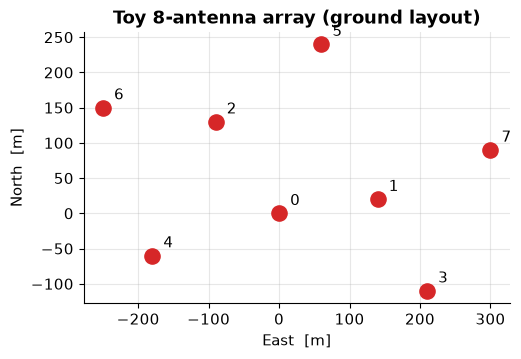

In [2]:
# Eight antennas scattered over ~600 m (positions in metres, planar array).
antenna_xy = np.array([
    [   0.0,    0.0],
    [ 140.0,   20.0],
    [ -90.0,  130.0],
    [ 210.0, -110.0],
    [ -180.0, -60.0],
    [  60.0,  240.0],
    [ -250.0, 150.0],
    [ 300.0,   90.0],
])
n_ant = antenna_xy.shape[0]
n_baselines = n_ant * (n_ant - 1) // 2
print(f"{n_ant} antennas  ->  {n_baselines} baselines")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(antenna_xy[:, 0], antenna_xy[:, 1], s=120, color="#d62728", zorder=3)
for i, (x, y) in enumerate(antenna_xy):
    ax.annotate(str(i), (x, y), textcoords="offset points", xytext=(8, 6))
ax.set_xlabel("East  [m]")
ax.set_ylabel("North  [m]")
ax.set_title("Toy 8-antenna array (ground layout)")
ax.set_aspect("equal")
plt.show()

Now compare two observations of the *same* array:

1. A **snapshot** — a single instant, `hour_angles=None`, which `uv_coverage`
   treats as hour angle 0. We get $N(N-1)/2$ baselines and their conjugates: a
   sparse scatter of points.
2. An **Earth-rotation track** — the same array observed across a range of hour
   angles as the source transits. Each baseline smears into an arc.

In [3]:
declination = np.deg2rad(80.0)  # source near the north celestial pole

# (1) Snapshot: a single instant.
uv_snapshot = interferometry.uv_coverage(antenna_xy, declination=declination)

# (2) Earth-rotation synthesis: track the source across +/- 6 hours of hour angle.
#     Hour angle advances at 15 deg/hour (the sky turns 360 deg in 24 h).
hours = np.linspace(-6.0, 6.0, 120)            # hours of hour angle
hour_angles = np.deg2rad(15.0 * hours)         # -> radians
uv_track = interferometry.uv_coverage(
    antenna_xy, hour_angles=hour_angles, declination=declination
)

print(f"snapshot : {uv_snapshot.shape[0]:5d} uv samples (incl. conjugates)")
print(f"rotation : {uv_track.shape[0]:5d} uv samples (incl. conjugates)")

snapshot :    56 uv samples (incl. conjugates)
rotation :  6720 uv samples (incl. conjugates)


The plot below is the heart of Earth-rotation synthesis. On the left, the bare
snapshot: a few dozen isolated points. On the right, the *same baselines* swept
through 12 hours of Earth rotation — each one has become an arc, and together
they paint a dense, roughly elliptical track through the $uv$-plane. We have
*synthesised* the aperture of a far larger instrument without moving a single
antenna.

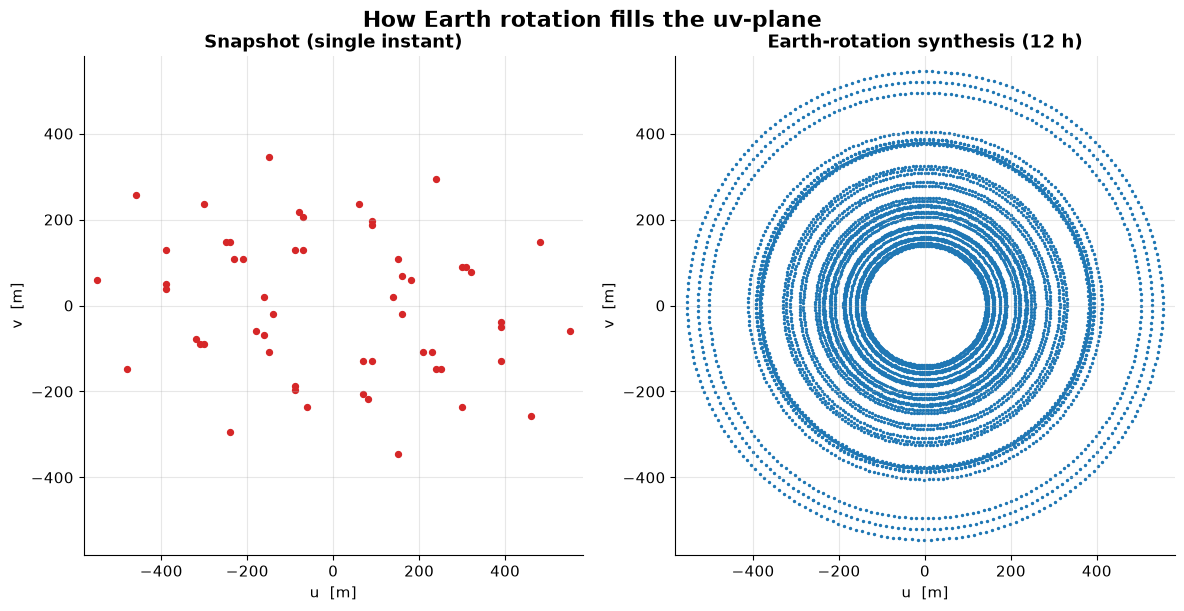

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_uv_coverage(uv_snapshot, ax=axes[0], s=18, color="#d62728")
axes[0].set_title("Snapshot (single instant)")
plot_uv_coverage(uv_track, ax=axes[1], s=2, color="#1f77b4")
axes[1].set_title("Earth-rotation synthesis (12 h)")

# Use the same axis limits so the density difference is obvious.
lim = 1.05 * np.abs(uv_track).max()
for ax in axes:
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
fig.suptitle("How Earth rotation fills the uv-plane", fontsize="x-large", weight="bold")
plt.tight_layout()
plt.show()

## A model sky, the dirty beam, and the dirty image

To see what this sampling *does to an image*, we need a sky to look at. We build
a small model on a `npix x npix` pixel grid: two compact point sources and one
soft extended "blob" (a Gaussian) — a miniature radio field.

Then:

- We grid the $uv$ samples onto a Fourier-plane mask with
  `interferometry.grid_visibilities`. This is the discrete sampling function
  $S(u, v)$.
- `interferometry.dirty_beam(sampling)` inverse-transforms that mask to give the
  **dirty beam** $B$ — the PSF of this particular observation.
- `interferometry.dirty_image(sky, sampling)` Fourier-transforms the model sky,
  keeps only the sampled visibilities, and transforms back — the **dirty image**
  $I_\mathrm{D} = I \ast B$.

In [5]:
npix = 256

def gaussian_blob(npix, row, col, amp, sigma):
    # A round Gaussian source centred at (row, col) on a npix x npix grid.
    yy, xx = np.mgrid[0:npix, 0:npix]
    r2 = (yy - row) ** 2 + (xx - col) ** 2
    return amp * np.exp(-r2 / (2.0 * sigma ** 2))

# Build the true sky: two point sources + one extended blob.
sky = np.zeros((npix, npix))
sky[120, 110] = 1.0                                   # bright point source
sky[150, 165] = 0.6                                   # fainter point source
sky += gaussian_blob(npix, row=110, col=150, amp=0.4, sigma=6.0)  # extended blob

# Grid the Earth-rotation uv samples onto a Fourier-plane sampling mask.
sampling = interferometry.grid_visibilities(uv_track, npix=npix)

# Dirty beam (PSF) and dirty image for this sampling.
beam = interferometry.dirty_beam(sampling)
dirty = interferometry.dirty_image(sky, sampling)

print("sky      :", sky.shape, " peak =", sky.max().round(3))
print("sampling :", sampling.shape, " filled cells =", int(sampling.sum()))
print("beam     :", beam.shape, " peak =", beam.max().round(3))
print("dirty    :", dirty.shape, " peak =", dirty.max().round(3))

sky      : (256, 256)  peak = 1.0
sampling : (256, 256)  filled cells = 5680
beam     : (256, 256)  peak = 1.0
dirty    : (256, 256)  peak = 0.087


Now the payoff figure. Four panels: the **true sky** (which a real telescope
never sees directly), the **sampling mask** in the $uv$-plane, the **dirty beam**,
and the **dirty image** the array actually produces.

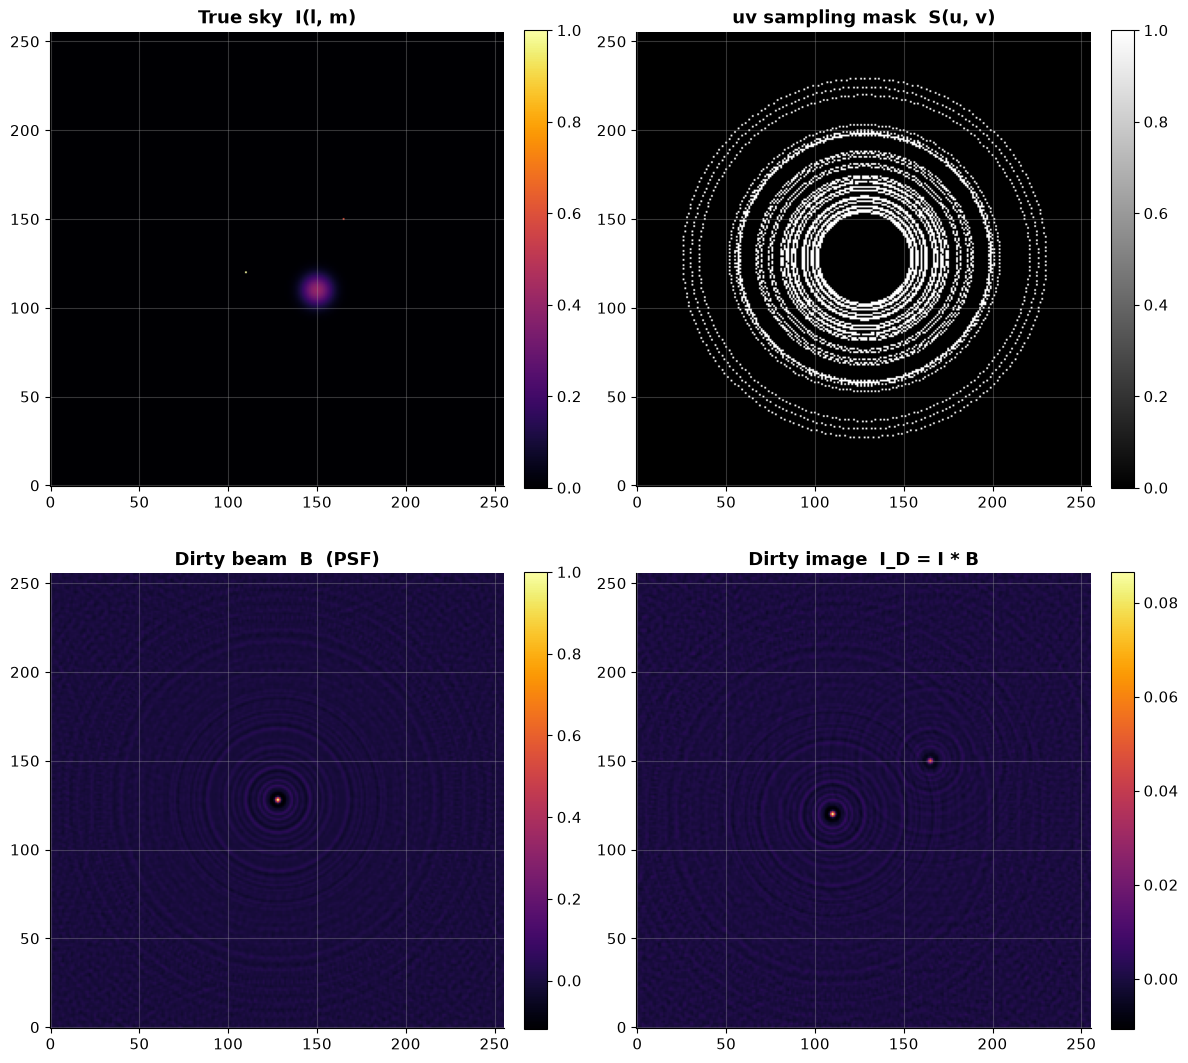

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 11))

show_image(sky, ax=axes[0, 0], title="True sky  I(l, m)")
show_image(sampling, ax=axes[0, 1], title="uv sampling mask  S(u, v)", cmap="gray")
show_image(beam, ax=axes[1, 0], title="Dirty beam  B  (PSF)", cmap="inferno")
show_image(dirty, ax=axes[1, 1], title="Dirty image  I_D = I * B")

plt.tight_layout()
plt.show()

### Reading the sidelobes

Look hard at the **dirty beam** (bottom left). It has a bright central core — the
*main lobe*, which sets the angular resolution — surrounded by a halo of fainter
ripples and radial spokes: the **sidelobes**. They are the direct fingerprint of
the *holes* in our $uv$ coverage. A perfectly, uniformly sampled $uv$-plane would
transform to a clean delta-like beam; every gap in the sampling shows up as a
sidelobe.

In the **dirty image** (bottom right) you can see the consequence: each true
source is reproduced not as a clean point but smeared by a copy of this beam.
The bright source throws sidelobe rings and spokes across the whole field, and
they overlap and interfere with the fainter source and the blob. *That* is why a
dirty image is not yet a science-quality image — and why we need CLEAN.

A 1-D slice through the centre of the beam makes the sidelobe levels quantitative:

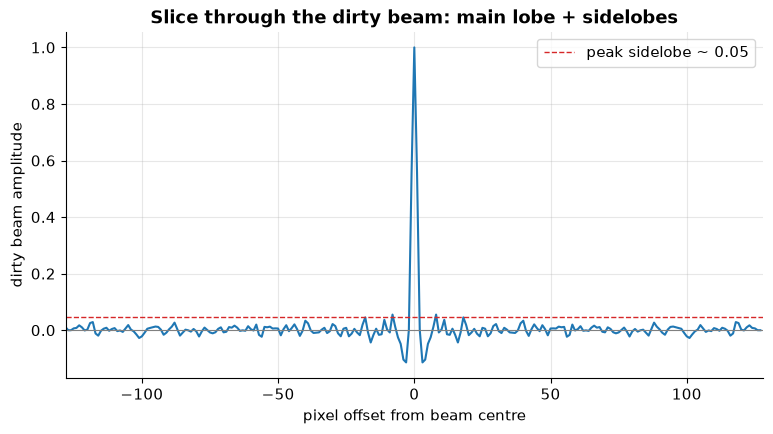

Peak sidelobe is ~5% of the main lobe.


In [7]:
center = npix // 2
slice_h = beam[center, :]              # horizontal cut through the beam centre
offset = np.arange(npix) - center

# Quantify the worst sidelobe (outside a small main-lobe exclusion zone).
exclude = 8
mask = np.abs(offset) > exclude
peak_sidelobe = np.abs(slice_h[mask]).max()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(offset, slice_h, color="#1f77b4")
ax.axhline(0.0, color="gray", lw=0.8)
ax.axhline(peak_sidelobe, color="#d62728", ls="--", lw=1.0,
           label=f"peak sidelobe ~ {peak_sidelobe:.2f}")
ax.set_xlabel("pixel offset from beam centre")
ax.set_ylabel("dirty beam amplitude")
ax.set_title("Slice through the dirty beam: main lobe + sidelobes")
ax.set_xlim(-npix // 2, npix // 2)
ax.legend()
plt.show()

print(f"Peak sidelobe is ~{100 * peak_sidelobe:.0f}% of the main lobe.")

## Making van Cittert–Zernike concrete

The claim from the physics section was specific: the dirty image is what you get
by **Fourier-transforming the sky, throwing away every visibility you did not
measure, and transforming back**. Let's not take `dirty_image` on faith — let's
reproduce it by hand, step by step, and check the two agree to numerical
precision.

In [8]:
# Step 1: Fourier-transform the true sky -> the *complete* visibility plane V(u, v).
#         (fftshift/ifftshift keep the zero-frequency component centred, matching
#          the convention used throughout jansky.interferometry.)
vis_full = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(sky)))

# Step 2: Apply the van Cittert-Zernike reality of a real array -- we only ever
#         measure V where the array has a baseline. Multiply by the sampling mask.
vis_sampled = vis_full * sampling

# Step 3: Inverse-transform the *sampled* visibilities back to the image plane.
dirty_manual = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis_sampled))).real

# Step 4: Compare against the helper's dirty_image.
max_abs_diff = np.abs(dirty_manual - dirty).max()
print(f"max |manual - dirty_image|  =  {max_abs_diff:.3e}")
print("Identical to numerical precision:", np.allclose(dirty_manual, dirty))

max |manual - dirty_image|  =  0.000e+00
Identical to numerical precision: True


They match to floating-point round-off. The hand-built pipeline — *FFT the sky,
mask with the $uv$ sampling, inverse-FFT* — **is** the dirty image. That is the
van Cittert–Zernike theorem, made tangible: the only reason our image is
imperfect is the multiplication by $S(u, v)$, the holes in the Fourier plane.

We can visualise that masking directly. Below: the full visibility amplitude
$|V|$ (what we wish we had), the sampled visibilities $|S\cdot V|$ (what we
actually keep), and the resulting dirty image. The middle panel is, quite
literally, our knowledge of the sky.

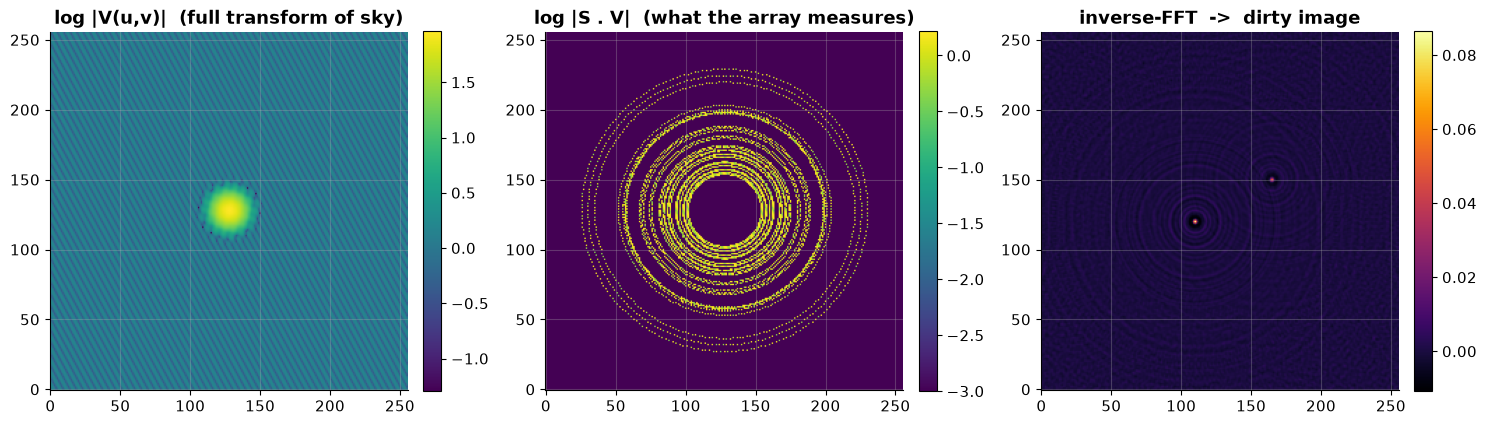

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))

# Log-stretch the visibility amplitudes so the structure is visible.
amp_full = np.log10(np.abs(vis_full) + 1e-3)
amp_samp = np.log10(np.abs(vis_sampled) + 1e-3)

show_image(amp_full, ax=axes[0], title="log |V(u,v)|  (full transform of sky)",
           cmap="viridis")
show_image(amp_samp, ax=axes[1], title="log |S . V|  (what the array measures)",
           cmap="viridis")
show_image(dirty_manual, ax=axes[2], title="inverse-FFT  ->  dirty image")

plt.tight_layout()
plt.show()

### Earth rotation buys you a better image

One more experiment ties the whole chapter together. We built the dirty image
above from the *Earth-rotation* sampling. What would the same sky look like
through the *snapshot* sampling — the sparse scatter of points from the very
first figure? Let's put the two dirty images side by side.

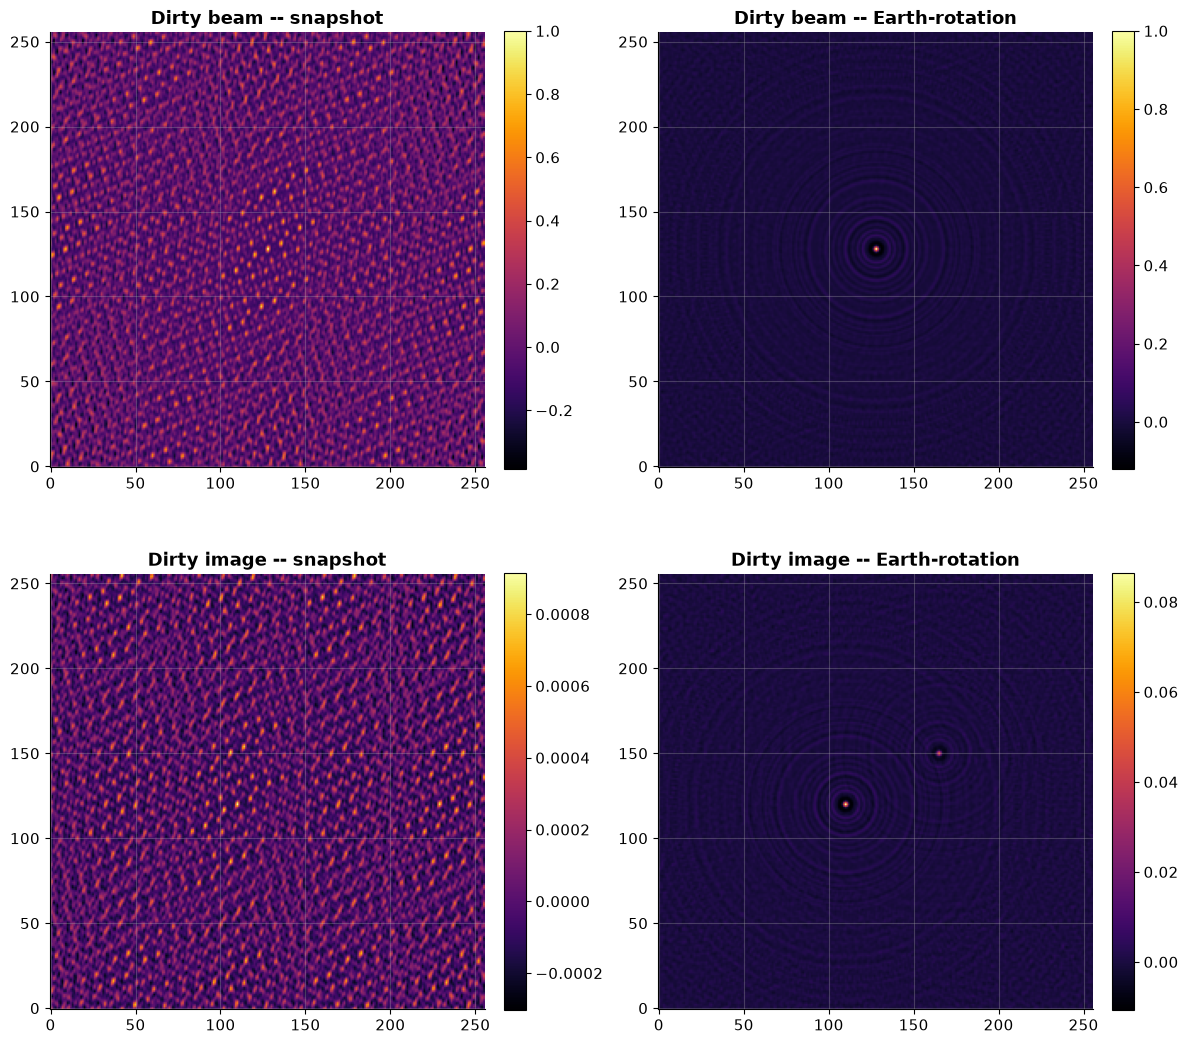

The snapshot beam is riddled with strong sidelobes; the snapshot dirty
image is barely recognisable. Earth rotation fills the uv-plane, shrinks
the sidelobes, and gives a dirty image you can actually start to read.


In [10]:
sampling_snap = interferometry.grid_visibilities(uv_snapshot, npix=npix)
beam_snap = interferometry.dirty_beam(sampling_snap)
dirty_snap = interferometry.dirty_image(sky, sampling_snap)

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
show_image(beam_snap, ax=axes[0, 0], title="Dirty beam -- snapshot")
show_image(beam, ax=axes[0, 1], title="Dirty beam -- Earth-rotation")
show_image(dirty_snap, ax=axes[1, 0], title="Dirty image -- snapshot")
show_image(dirty, ax=axes[1, 1], title="Dirty image -- Earth-rotation")
plt.tight_layout()
plt.show()

print("The snapshot beam is riddled with strong sidelobes; the snapshot dirty")
print("image is barely recognisable. Earth rotation fills the uv-plane, shrinks")
print("the sidelobes, and gives a dirty image you can actually start to read.")

## Try it yourself

1. **Declination matters.** In `uv_coverage`, the $v$ projection is scaled by
   $\sin(\delta)$. Re-run the Earth-rotation coverage for a source on the
   celestial equator (`declination = np.deg2rad(0.0)`) and one near the pole
   (`80°`). How does the shape of the $uv$ track — and the resulting dirty beam —
   change? (This is why arrays observe sources near the pole when they want the
   roundest beam.)

2. **More antennas, fewer holes.** Add a few antennas to `antenna_xy`, or spread
   them over a larger area. Re-grid, recompute the dirty beam, and measure the
   peak sidelobe with the 1-D slice. Does adding antennas help more than adding
   observing time (more hour angles)?

3. **A harder sky.** Replace the model `sky` with a cluster of several faint
   point sources close together, or a thin extended filament. Which features
   survive the dirty beam, and which get buried in sidelobes? Make a prediction
   first, then check it. This is exactly the situation CLEAN is built to rescue.

4. **(Stretch) The shortest baseline.** The smallest $|(u,v)|$ you measure sets
   the largest angular scale you are sensitive to — emission smoother than that
   is "resolved out". Find the minimum non-zero baseline length in your array
   and relate it to the size of the largest blob your dirty image can faithfully
   reproduce.

<details><summary>Solution 1 — Declination matters</summary>

The `v` projection in `uv_coverage` is scaled by $\sin(\delta)$, so at the
equator ($\delta = 0$) every sample collapses onto the $u$-axis: the
Earth-rotation track degenerates to a flat line and there is essentially no
$v$-coverage. Near the pole ($\delta = 80°$) the tracks open up into broad,
nearly circular ellipses, giving a far rounder beam.

```python
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for col, dec_deg in enumerate((0.0, 80.0)):
    dec = np.deg2rad(dec_deg)
    uv = interferometry.uv_coverage(
        antenna_xy, hour_angles=hour_angles, declination=dec
    )
    samp = interferometry.grid_visibilities(uv, npix=npix)
    bm = interferometry.dirty_beam(samp)
    plot_uv_coverage(uv, ax=axes[0, col], s=2, color="#1f77b4")
    axes[0, col].set_title(f"uv track, dec = {dec_deg:.0f} deg")
    show_image(bm, ax=axes[1, col], title=f"dirty beam, dec = {dec_deg:.0f} deg",
               cmap="inferno")
    print(f"dec = {dec_deg:4.0f} deg : v-extent = {np.abs(uv[:, 1]).max():6.1f} m")
plt.tight_layout()
plt.show()
```

Expected: the equatorial run prints `v-extent = 0.0 m` (a 1-D track and a badly
elongated beam), while at 80° the v-extent is ~545 m and the beam is round. **This
is why arrays observe near the pole when they want the roundest synthesised beam.**

</details>

<details><summary>Solution 2 — More antennas vs more time</summary>

Add a few antennas, re-grid, and measure the peak sidelobe with the same 1-D
slice used earlier. Compare against simply piling on more hour angles.

```python
def peak_sidelobe(beam, exclude=8):
    c = npix // 2
    off = np.arange(npix) - c
    return np.abs(beam[c, :][np.abs(off) > exclude]).max()

# (a) four extra antennas spread the array wider -> new baseline families.
extra = np.array([[-50.0, -200.0], [170.0, 180.0],
                  [-300.0, -150.0], [260.0, -250.0]])
antenna_more = np.vstack([antenna_xy, extra])
uv_more = interferometry.uv_coverage(
    antenna_more, hour_angles=hour_angles, declination=declination)
beam_more = interferometry.dirty_beam(interferometry.grid_visibilities(uv_more, npix=npix))

# (b) same 8 antennas, 4x as many hour angles -> denser arcs, no new baselines.
ha_dense = np.deg2rad(15.0 * np.linspace(-6.0, 6.0, 480))
uv_dense = interferometry.uv_coverage(
    antenna_xy, hour_angles=ha_dense, declination=declination)
beam_dense = interferometry.dirty_beam(interferometry.grid_visibilities(uv_dense, npix=npix))

print(f"baseline (8 ant, 120 HA) : {peak_sidelobe(beam):.3f}")
print(f"12 antennas, 120 HA      : {peak_sidelobe(beam_more):.3f}")
print(f"8 antennas, 480 HA       : {peak_sidelobe(beam_dense):.3f}")
```

Expected: extra antennas cut the peak sidelobe sharply (~0.045 → ~0.02), while
4× more time barely moves it (~0.045 → ~0.043). **Adding antennas wins:** new
antennas add whole new baseline lengths/orientations, whereas more hour angles
only densify the arcs you already have.

</details>

<details><summary>Solution 3 — A harder sky</summary>

Swap in a cluster of faint, closely-spaced point sources and rebuild the dirty
image with the *same* Earth-rotation `sampling`. Predict first: sources separated
by less than the main-lobe width blur together, and faint sources sitting on a
bright source's sidelobe rings get buried.

```python
sky2 = np.zeros((npix, npix))
for (r, c, amp) in [(120, 120, 1.0), (128, 132, 0.4), (134, 124, 0.35),
                    (122, 138, 0.3), (140, 140, 0.25)]:
    sky2[r, c] = amp

dirty2 = interferometry.dirty_image(sky2, sampling)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
show_image(sky2, ax=axes[0], title="True sky (faint cluster)")
show_image(dirty2, ax=axes[1], title="Dirty image  I_D = I * B")
plt.tight_layout()
plt.show()
```

Expected: the brightest source dominates and throws sidelobes across its
neighbours; the closest/faintest companions merge into the main lobe or vanish
into the sidelobe halo. **This is exactly the confusion CLEAN (Chapter 9) is
built to undo** by subtracting each source's beam before the next is measured.

</details>

<details><summary>Solution 4 (stretch) — The shortest baseline</summary>

The largest angular scale an array is sensitive to is set by its **shortest**
baseline: the fringe spacing $\sim \lambda / b_\mathrm{min}$. Emission smoother
than that fringe is "resolved out". Find $b_\mathrm{min}$ from the antenna
layout (and confirm against the minimum non-zero sampled $|(u,v)|$).

```python
diffs = antenna_xy[:, None, :] - antenna_xy[None, :, :]   # all pair separations
lengths = np.hypot(diffs[..., 0], diffs[..., 1])
b_min = lengths[lengths > 0].min()
b_max = lengths[lengths > 0].max()

r = np.hypot(uv_track[:, 0], uv_track[:, 1])              # sampled uv radii
r_min = r[r > 1e-6].min()

print(f"shortest baseline   b_min = {b_min:6.1f} m")
print(f"longest baseline    b_max = {b_max:6.1f} m")
print(f"min sampled |uv|          = {r_min:6.1f} m")
print(f"resolution / max-scale ratio  b_min/b_max = {b_min / b_max:.2f}")
```

Expected: `b_min` ≈ 141 m and `b_max` ≈ 553 m. The shortest baseline (~141 m)
fixes the coarsest fringe the array can record, so any blob broader than
$\sim\lambda/b_\mathrm{min}$ on the sky is over-resolved and lost. With
$b_\mathrm{min}/b_\mathrm{max} \approx 0.26$ this array spans only a modest range
of scales — a real instrument adds compact "short-spacing" antennas precisely to
keep large-scale structure.

</details>

## Recap

- **An interferometer is a Fourier machine.** By the **van Cittert–Zernike
  theorem**, each baseline measures one visibility $V(u, v)$ — one Fourier
  component of the sky brightness $I(l, m)$ — at the spatial frequency $(u, v)$
  set by that baseline, plus its conjugate.
- A real array samples the Fourier plane only where it has baselines: the
  **sampling function** $S(u, v)$ is full of holes.
- **Earth-rotation synthesis** (Ryle's Nobel-winning idea) sweeps each baseline
  into an arc as the planet turns, filling in the $uv$-plane for free and turning
  a sparse snapshot into a richly sampled aperture.
- The inverse transform of $S$ is the **dirty beam** $B$ (the PSF), and the image
  we recover is the **dirty image** $I_\mathrm{D} = I \ast B$ — the true sky
  smeared by that beam. The beam's **sidelobes** scatter flux across the field,
  which is why the dirty image is not yet science-ready.
- We verified the relationship by hand: *FFT the sky $\to$ multiply by the
  sampling mask $\to$ inverse-FFT* reproduces `dirty_image` exactly.

## What's next — Chapter 9: CLEAN

We are left holding a dirty image: the true sky convolved with a sidelobe-ridden
dirty beam. The natural question is whether we can *undo* that convolution and
recover the sky. We can — approximately — and the algorithm that made
aperture-synthesis imaging practical is **Högbom's CLEAN** (1974). In
**Chapter 9** we will take the very `dirty` and `beam` arrays from this notebook,
feed them to `interferometry.hogbom_clean`, and watch a clean image emerge — one
sidelobe at a time.